In [15]:
import pybedtools, os, re, pickle
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.lines as lines
from scipy.cluster import hierarchy
from matplotlib.lines import Line2D   
import itertools

from scipy.stats import zscore

from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.colors import LinearSegmentedColormap

## 1. How do F1 scores relate to distance to reference cell line?

In [33]:
def smooth_lowess(group):
    smoothed = lowess(group['f1_mean'], group['cell_line_dist'], frac=0.4, return_sorted=False)
    return pd.Series(smoothed, index=group.index)


def _linePlots_local(df, metric, ax):
    
    def smooth_lowess(group, metric):
        smoothed = lowess(group[f'{metric}_mean'], group['cell_line_dist'], frac=0.4, return_sorted=False)
        return pd.Series(smoothed, index=group.index)

    cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)

    df = df.sort_values(['value', f'{metric}_mean'])
    df['y_smooth'] = df.groupby('value', group_keys=False).apply(lambda group: smooth_lowess(group, metric), include_groups=False)
    
    ax=sns.scatterplot(data=df, x="cell_line_dist", y=f'{metric}_mean', hue='value', 
                    alpha=0.7, marker="o", legend=False, ax=ax, palette=cmap,
                    s=100, linewidth=0) 
    ax=sns.lineplot(data=df, x="cell_line_dist", y='y_smooth', hue='value', 
                 linewidth=1.5, ax=ax, legend=legend,  palette=cmap)
    
    ax.set_xlim(0.1,0.75)
    
    #ax0.set_xlabel("Average Distance to Cell-Line Center")
    #ax0.set_ylabel(metric)
    
    
    ax.grid(which='major', color='#DDDDDD', linewidth=0.4)
    ax.tick_params(axis='both', labelsize=15)
    return ax

#### Effect of Peak Coverage

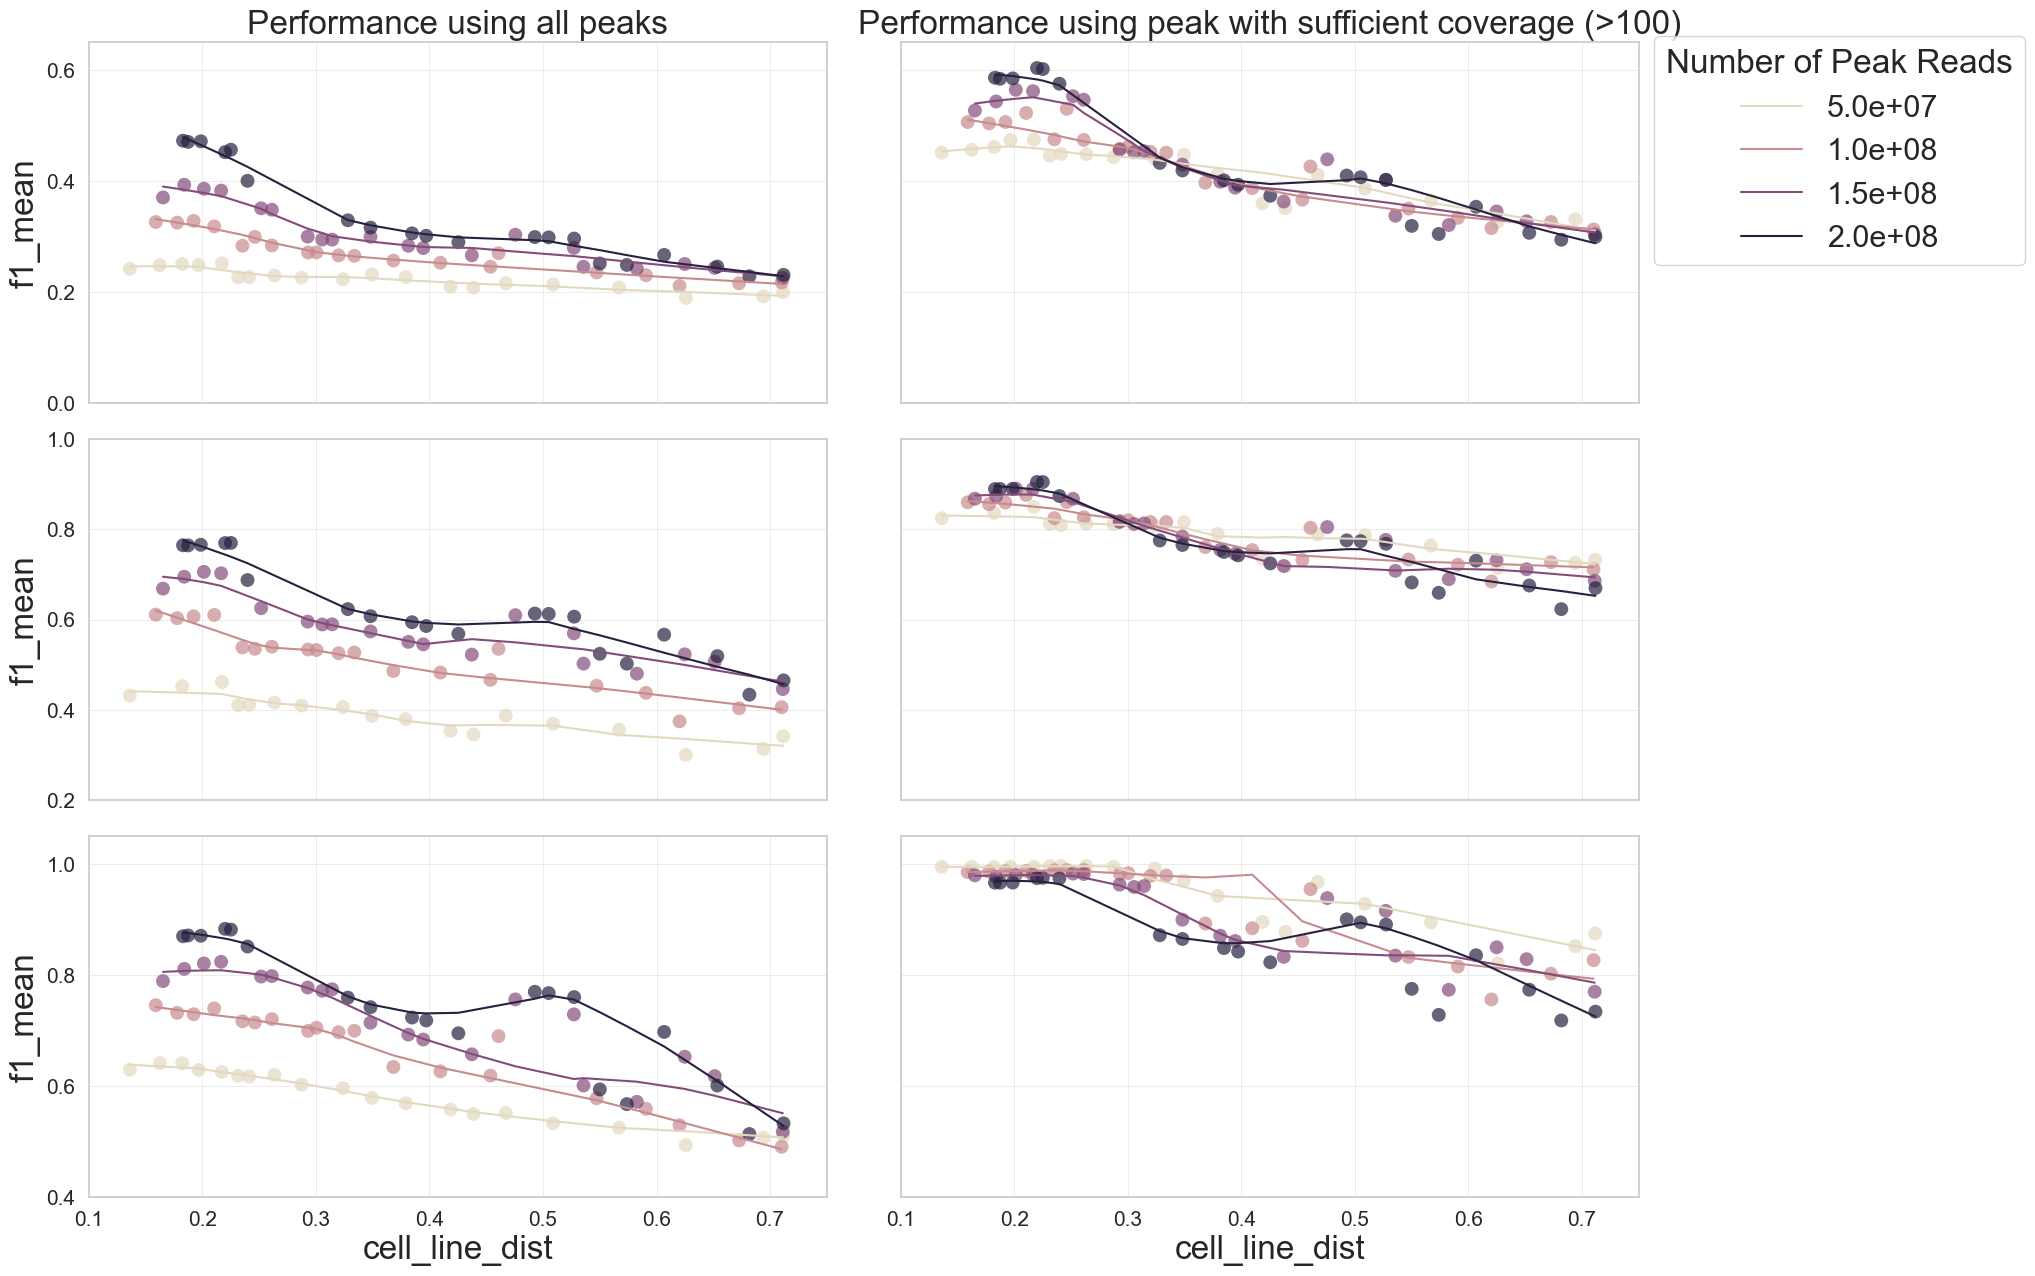

In [34]:
import matplotlib.ticker as mticker
fig, axes = plt.subplots(3, 2, figsize=(20,15))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.1, hspace=0.1)
sns.set(font_scale=2, style='whitegrid')

pulled_legend = False
for i, (t, metric_dir), in enumerate(list(itertools.product(["hint", "print", "tobias"], ["metrics", "metrics_100"]))):
    #data_dir = f"/pollard/data/projects/aseveritt/encode_snatacseq/07_cellsim/" 
    df = pd.read_csv(f"{t}/{metric_dir}/{t}_bytf_limitedTFset.csv.gz", sep=",", index_col=0)
    df.value = df.value.astype(int)
    ax0 = _linePlots_local(df.copy(), "f1", axes[i])

    if i==0:
        ax0.set_title("Performance using all peaks")
    
    if i==1:
        ax0.legend(loc='center left', bbox_to_anchor=(1, 0.7), title="Number of Peak Reads") 
        legend = ax0.get_legend()
        for text in legend.get_texts():
            value = float(text.get_text())
            text.set_text(f'{value:.1e}')
        ax0.set_title("Performance using peak with sufficient coverage (>100)")
    else:
        ax0.legend_.remove()
    
    if t == "hint":
        ax0.set_ylim(0.1,0.65)
        ax0.set_yticks([0, 0.2, 0.4, 0.6])
    elif t == "print":
        #x0.set_ylim(0.2,1)
        ax0.set_yticks([0.2, 0.4, 0.6, 0.8, 1])
    elif t == "tobias":
        ax0.set_ylim(0.4,1.05)
        ax0.set_yticks([0.4, 0.6, 0.8, 1])

    if i not in [0,2,4]:
        ax0.set_yticklabels([]); ax0.set_ylabel("")
        
    if i not in [4,5]:
        ax0.set_xticklabels([]); ax0.set_xlabel("")
        
        
plt.show()

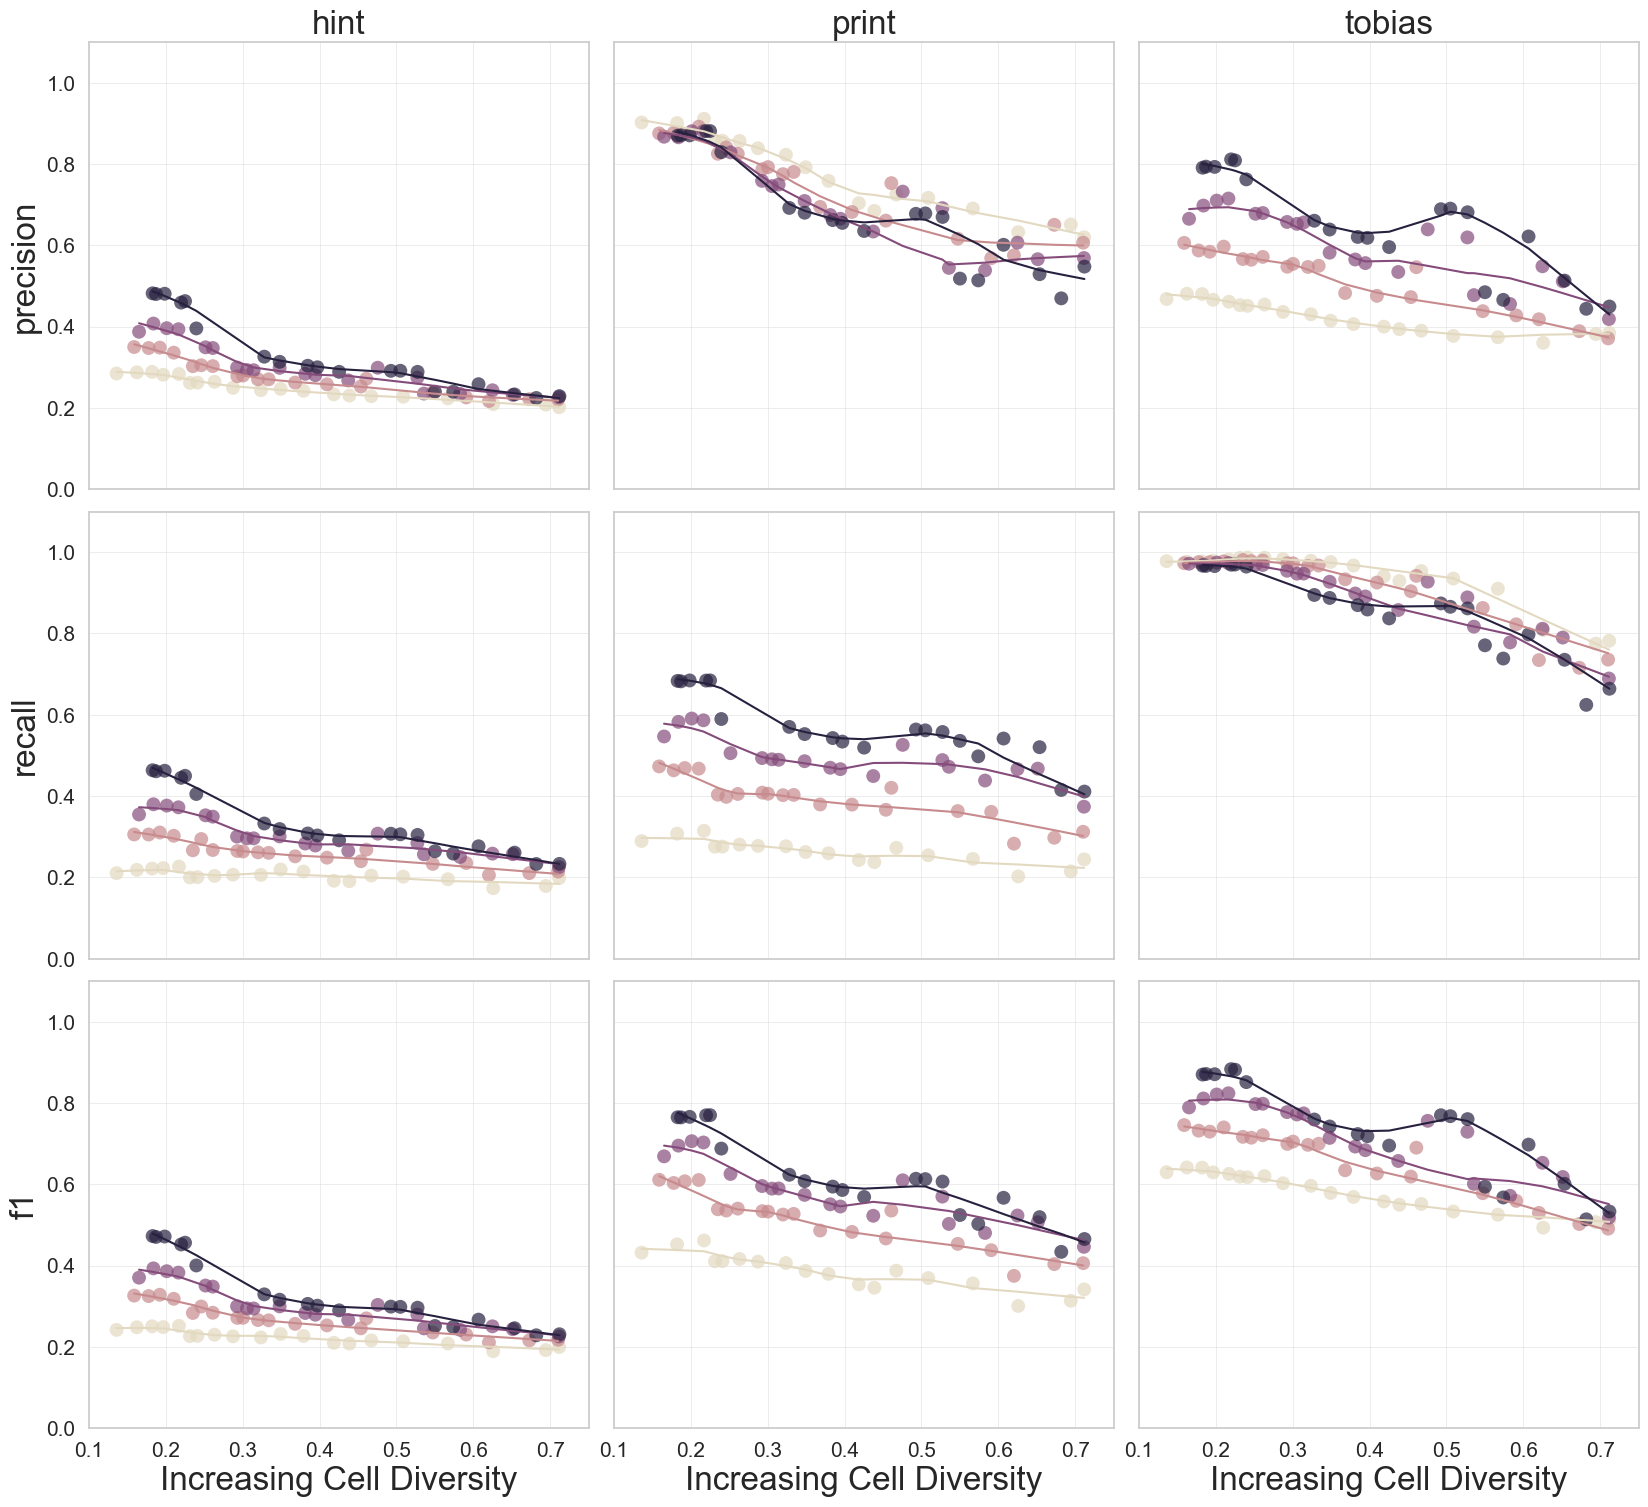

In [37]:
fig, axes = plt.subplots(3, 3, figsize=(20,18))
axes = axes.flatten()  # Flatten to iterate easily
plt.subplots_adjust(wspace=0.05, hspace=0.05)
sns.set(font_scale=2, style='whitegrid')

pulled_legend = False
for metric, i in zip(["precision", "recall", "f1"], [0,3,6]):

    for t, j in zip(["hint", "print", "tobias"], [0,1,2]):
        df = pd.read_csv(f"{t}/metrics/{t}_bytf_limitedTFset.csv.gz", sep=",", index_col=0)
        df.value = df.value.astype(int)
    
        ax0 = _linePlots_local(df.copy(), metric, axes[i+j])
        if (i + j) not in [0,3,6]:
            ax0.set_yticklabels([]); ax0.set_ylabel("")
        if (i + j) not in [6,7,8]:
            ax0.set_xticklabels([]); ax0.set_xlabel("")

        if (i + j) in [0,1,2]:
            ax0.set_title(t)
            
        if (i + j) in [0,3,6]:
            ax0.set_ylabel(metric)

        if (i + j) in [6,7,8]:
            ax0.set_xlabel("Increasing Cell Diversity")
            
        ax0.legend_.remove()
        ax0.set_ylim(0,1.1)
        
plt.show()


## 2. Can we show how CT-specific TFs in/decrease as a function of population makeup?

In [42]:
tool = "print"

#1. Read in the sample info so we know what the references were make to. 
all_metrics = pd.read_csv("../04_downsampling/05_cellsim/similarity_summary_stats.csv", sep=",")
all_metrics["filename"] = [i.replace('.bam', '.mat') for i in all_metrics["filename"].values]

#2. Get metric file for all samples
metric_dir = f"../../07_cellsim/{tool}/metrics/" 
files = [x for x in os.listdir(metric_dir) if x.startswith("combo")]

df = pd.DataFrame()
for f in files:
    name, ref_to = f.split("_")[1:3]
    tmp = pd.read_csv(f"{metric_dir}/{f}", sep=",", index_col=0)
    tmp = tmp.dropna() #need for print
    tmp["NFootprints"] = tmp["TP"] + tmp["FP"]
    tmp["Footprint_zscore"] = tmp[["NFootprints"]].apply(zscore)
    
    extra_info = all_metrics[(all_metrics["ComboID"] == int(name)) & (all_metrics["dist_to_*"] == ref_to)].iloc[0]
    tmp2 = tmp.assign(**extra_info)  # Assign new columns
    
    df= pd.concat([df, tmp2])


display(df)

,TP,FP,FN,TN,precision,recall,f1,type,NFootprints,Footprint_zscore,...,closest_cell_line,cell_line_dist,Ncells,dist_to_*,cell_line_proportions,sampling_type,filename,Nreadpairs,Nnonpeakpairs,FRIP
BATF::JUN_MA0462.2,9278,725,12145,1164874,0.927522,0.433086,0.590466,tf,10003,0.443163,...,GM12878,0.159037,7000,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827
FOSB::JUNB_MA1135.1,11245,706,14091,1167361,0.940925,0.443835,0.603159,tf,11951,0.700042,...,GM12878,0.159037,7000,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827
JUNB_MA0490.2,8361,575,11090,1169141,0.935654,0.429849,0.589072,tf,8936,0.302459,...,GM12878,0.159037,7000,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827
FOSL1_MA0477.2,10389,690,13408,1165661,0.937720,0.436568,0.595768,tf,11079,0.585053,...,GM12878,0.159037,7000,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827
MAF_MA1520.1,4901,501,5919,1178492,0.907257,0.452957,0.604241,tf,5402,-0.163564,...,GM12878,0.159037,7000,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF214_MA1975.1,801,539,3917,1180138,0.597761,0.169775,0.264444,tf,1340,-0.525516,...,GM12878,0.438816,4000,K562,"{'HEPG2': 2000, 'K562': 2000}",cell_sim,combo_2.mat,261428331,211483051,0.191048
TFCP2L1_MA0145.2,3584,1468,9792,1171286,0.709422,0.267943,0.388973,tf,5052,0.081336,...,GM12878,0.438816,4000,K562,"{'HEPG2': 2000, 'K562': 2000}",cell_sim,combo_2.mat,261428331,211483051,0.191048
GATA1::TAL1_MA0140.2,3252,540,8509,1173333,0.857595,0.276507,0.418183,tf,3792,-0.124653,...,GM12878,0.438816,4000,K562,"{'HEPG2': 2000, 'K562': 2000}",cell_sim,combo_2.mat,261428331,211483051,0.191048
ZBTB32_MA1580.1,676,413,3737,1180695,0.620753,0.153184,0.245729,tf,1089,-0.566551,...,GM12878,0.438816,4000,K562,"{'HEPG2': 2000, 'K562': 2000}",cell_sim,combo_2.mat,261428331,211483051,0.191048


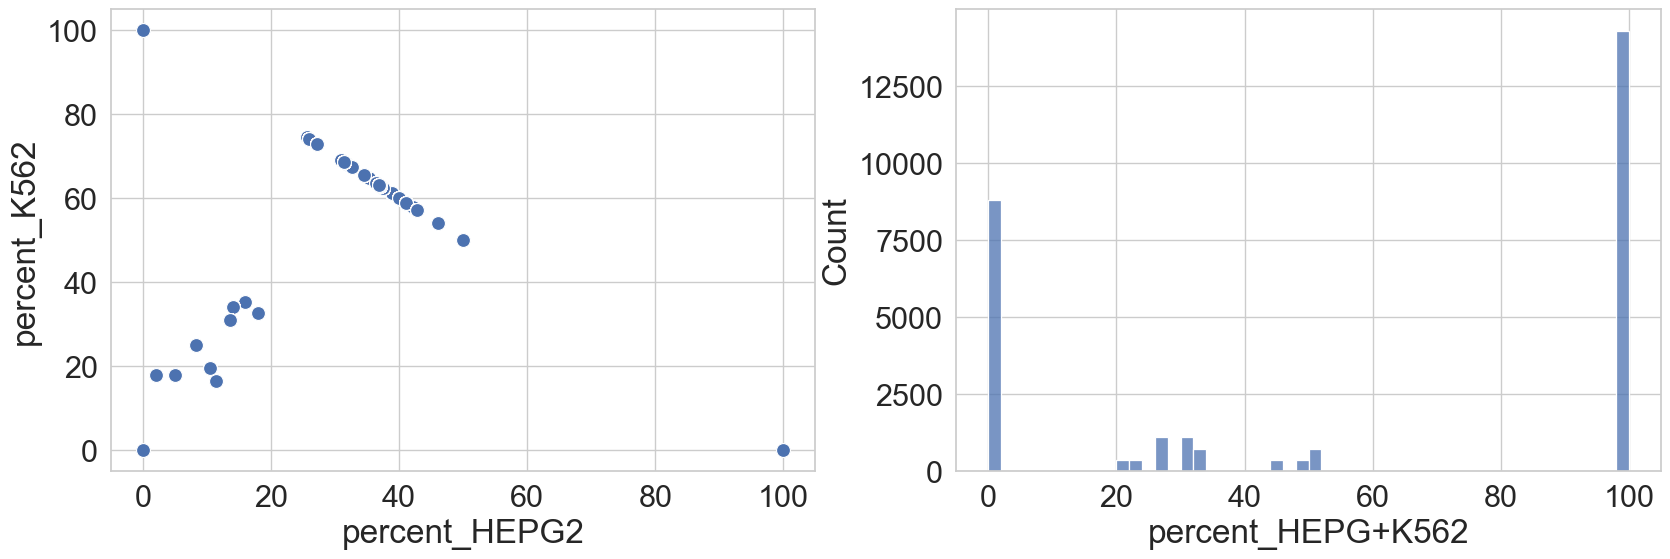

Of the 63 samples, 34 are made up of only HEPG2 and K562


,TP,FP,FN,TN,precision,recall,f1,type,NFootprints,Footprint_zscore,...,dist_to_*,cell_line_proportions,sampling_type,filename,Nreadpairs,Nnonpeakpairs,FRIP,percent_HEPG2,percent_K562,percent_HEPG+K562
BATF::JUN_MA0462.2,9278,725,12145,1164874,0.927522,0.433086,0.590466,tf,10003,0.443163,...,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827,100.0,0.0,100.0
FOSB::JUNB_MA1135.1,11245,706,14091,1167361,0.940925,0.443835,0.603159,tf,11951,0.700042,...,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827,100.0,0.0,100.0
JUNB_MA0490.2,8361,575,11090,1169141,0.935654,0.429849,0.589072,tf,8936,0.302459,...,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827,100.0,0.0,100.0
FOSL1_MA0477.2,10389,690,13408,1165661,0.937720,0.436568,0.595768,tf,11079,0.585053,...,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827,100.0,0.0,100.0
MAF_MA1520.1,4901,501,5919,1178492,0.907257,0.452957,0.604241,tf,5402,-0.163564,...,HEPG2,{'HEPG2': 7000},cell_sim,combo_34.mat,551313655,446108096,0.190827,100.0,0.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNF214_MA1975.1,801,539,3917,1180138,0.597761,0.169775,0.264444,tf,1340,-0.525516,...,K562,"{'HEPG2': 2000, 'K562': 2000}",cell_sim,combo_2.mat,261428331,211483051,0.191048,50.0,50.0,100.0
TFCP2L1_MA0145.2,3584,1468,9792,1171286,0.709422,0.267943,0.388973,tf,5052,0.081336,...,K562,"{'HEPG2': 2000, 'K562': 2000}",cell_sim,combo_2.mat,261428331,211483051,0.191048,50.0,50.0,100.0
GATA1::TAL1_MA0140.2,3252,540,8509,1173333,0.857595,0.276507,0.418183,tf,3792,-0.124653,...,K562,"{'HEPG2': 2000, 'K562': 2000}",cell_sim,combo_2.mat,261428331,211483051,0.191048,50.0,50.0,100.0
ZBTB32_MA1580.1,676,413,3737,1180695,0.620753,0.153184,0.245729,tf,1089,-0.566551,...,K562,"{'HEPG2': 2000, 'K562': 2000}",cell_sim,combo_2.mat,261428331,211483051,0.191048,50.0,50.0,100.0


In [43]:
#Add the percent of our two CLs of interest. 

import ast
def add_CL_percent(row, cl):
    local_dict = row["cell_line_proportions"]
    local_dict = ast.literal_eval(local_dict)
    try:
        val = local_dict[cl]
    except:
        val = 0

    return (val/row.Ncells) *100

df["percent_HEPG2"] = df.apply(lambda row: add_CL_percent(row, cl="HEPG2"), axis=1)
df["percent_K562"] = df.apply(lambda row: add_CL_percent(row, cl="K562"), axis=1)
df["percent_HEPG+K562"] = df["percent_HEPG2"] + df["percent_K562"]

fig = plt.figure(figsize=(20,6))
gs = GridSpec(1,2, figure=fig, hspace=0.5)

ax0 = fig.add_subplot(gs[0])
sns.scatterplot(data=df, x="percent_HEPG2", y="percent_K562", s=100)

ax0 = fig.add_subplot(gs[1])
sns.histplot(df["percent_HEPG+K562"], bins =50)
plt.show()

print(f'Of the {len(np.unique(df["ComboID"]))} samples, {len(np.unique(df[(df["percent_HEPG+K562"] > 80)]["ComboID"]))} are made up of only HEPG2 and K562')
display(df)

In [44]:
#Which TFs have the biggest correlation to the percent of either cell line, 
#should be CT specific ones.

def compute_corrs(group):
    col = "NFootprints"
    #col = "Footprint_zscore"
    return pd.Series({
        "corr_HEPG2": group[col].corr(group["percent_HEPG2"]),
        "corr_K562": group[col].corr(group["percent_K562"])
    })

df["tf"] = df.index
corr_df = df.groupby("tf").apply(compute_corrs, include_groups=False).reset_index()
corr_df["diff"] = corr_df.corr_HEPG2 - corr_df.corr_K562
display(corr_df.sort_values("diff", ascending=False)[1:5])
display(corr_df.sort_values("diff", ascending=True)[1:5])

corr_df["abs_diff"] = abs(corr_df["diff"])
display(corr_df.sort_values("abs_diff", ascending=True)[1:10])


,tf,corr_HEPG2,corr_K562,diff
117,HNF4A_MA0114.4,0.731996,0.305684,0.426312
118,HNF4G_MA0484.2,0.733011,0.307575,0.425436
220,ONECUT2_MA0756.2,0.663803,0.315398,0.348405
34,CUX1_MA0754.2,0.636003,0.304378,0.331625


,tf,corr_HEPG2,corr_K562,diff
327,ZBTB33_MA0527.1,0.009884,0.741917,-0.732033
199,NFYC_MA1644.1,-0.166651,0.541478,-0.708129
99,GATA6_MA1104.2,0.092508,0.706319,-0.613811
255,RFX5_MA0510.2,-0.185072,0.346136,-0.531208


,tf,corr_HEPG2,corr_K562,diff,abs_diff
247,PRDM15_MA1616.1,0.093408,0.097888,-0.004480,0.004480
240,POU4F2_MA0683.1,-0.051101,-0.044031,-0.007070,0.007070
26,CEBPG_MA1636.1,0.369983,0.378434,-0.008452,0.008452
157,LHX3_MA0135.1,-0.098159,-0.088238,-0.009921,0.009921
265,SCRT1_MA0743.2,0.145388,0.134013,0.011376,0.011376
33,CTCF_MA1929.1,0.204961,0.220083,-0.015122,0.015122
315,THAP1_MA0597.2,0.263482,0.246009,0.017473,0.017473
90,FOXH1_MA0479.1,0.170137,0.152521,0.017617,0.017617
275,SOX15_MA1152.1,0.178056,0.197760,-0.019704,0.019704


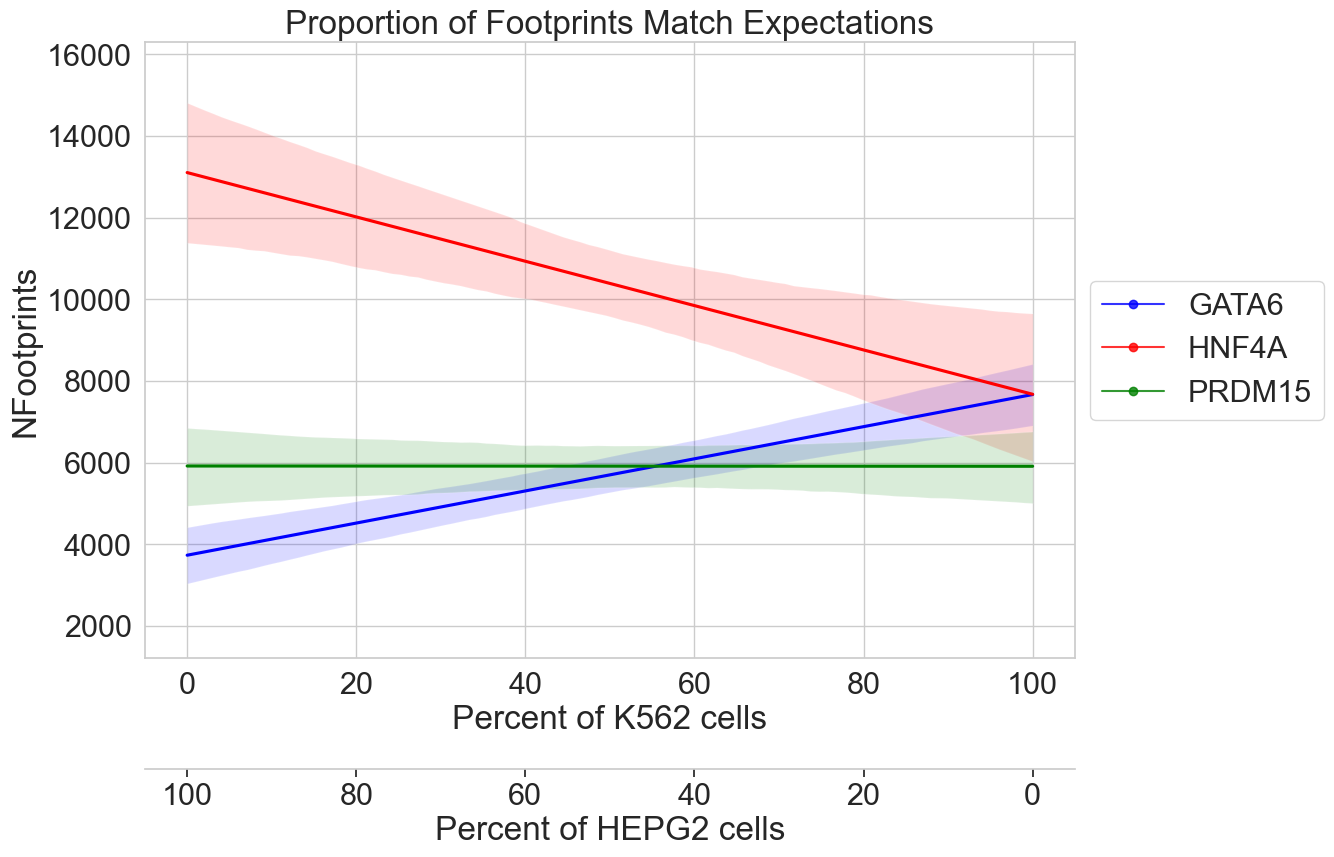

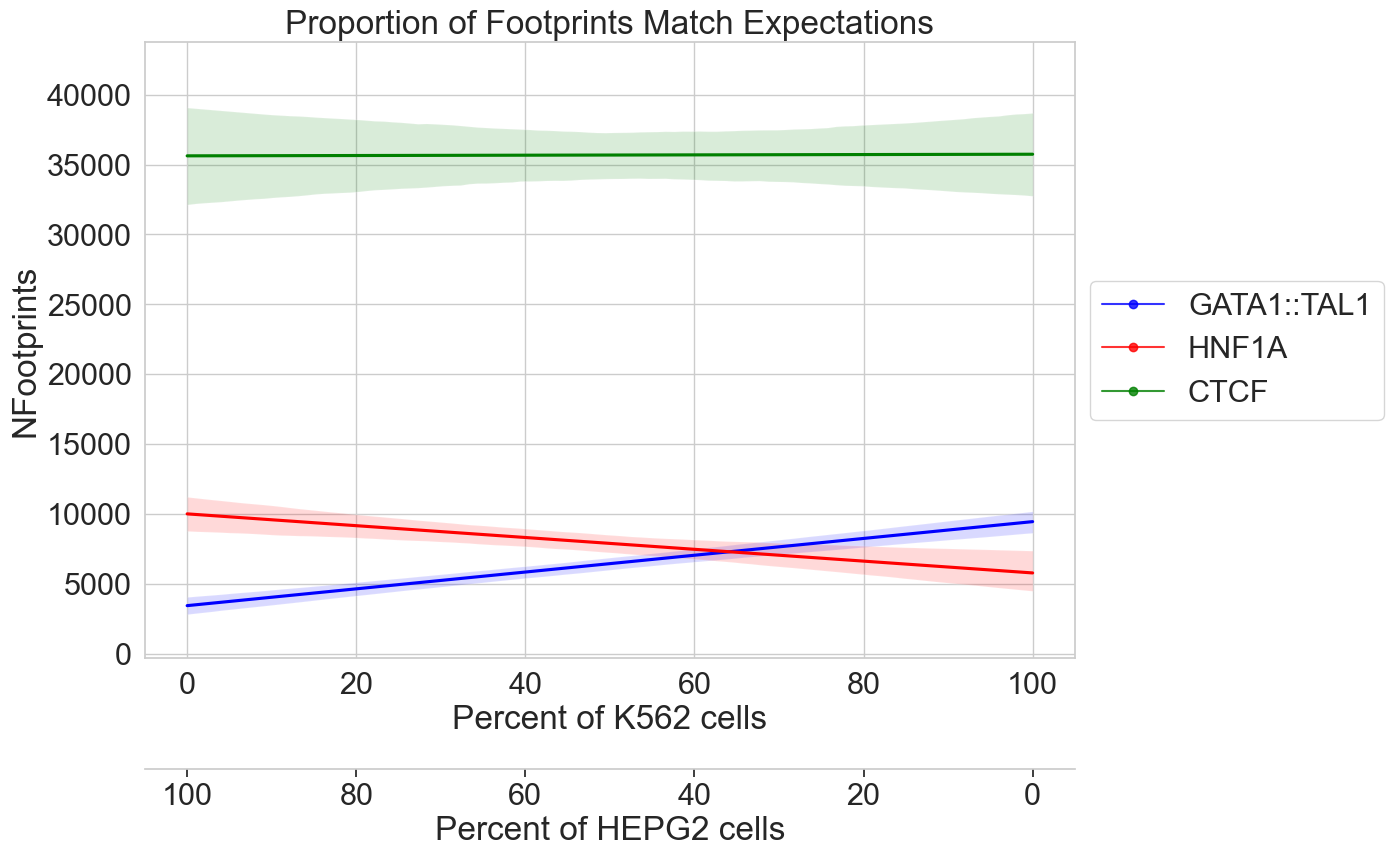

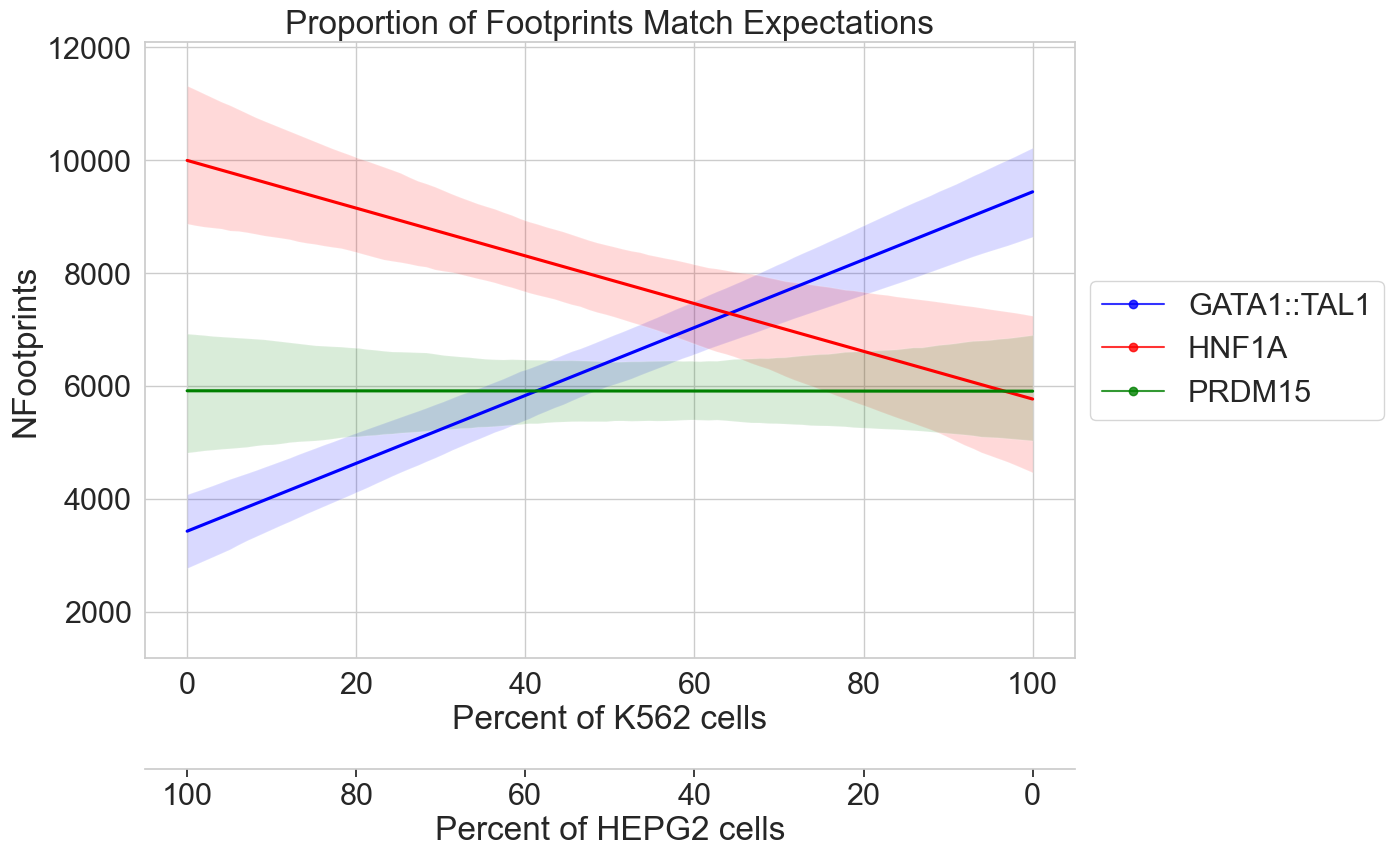

In [45]:
def CoolRegressionPlot(tfs):
    import matplotlib.lines as mlines
    fig = plt.figure(figsize=(12, 8))
    gs = GridSpec(1,1, figure=fig, hspace=0.5)
    colors = ["blue", "red","green", "orange", "pink"]
    
    x1 = "percent_K562"
    x2 = "percent_HEPG2"
    y = "NFootprints"
    #y = "Footprint_zscore"
    
    ax1 = fig.add_subplot(gs[0])
    
    tmp = df[(df.tf.isin(tfs)) & (df["percent_HEPG+K562"] > 80)]# & (df["value"].isin([1e8, 2e8]))]
    for i, tf in enumerate(tfs):
        color = colors[i]
        name = tf.split("_")[0]
        sns.regplot(data=tmp[tmp.tf == tf], x=x1, y=y, ax=ax1, color=color, marker='o', scatter_kws={"s": 0}, label=name)
    
    coeffs = np.polyfit(tmp[x1].values, tmp[x2].values, deg=1)
    x1_to_x2 = np.poly1d(coeffs)
    coeffs = np.polyfit(tmp[x2].values, tmp[x1].values, deg=1)
    x2_to_x1 = np.poly1d(coeffs)
    ax2 = ax1.secondary_xaxis('bottom', functions=(x1_to_x2, x2_to_x1))
    ax2.spines['bottom'].set_position(('outward', 80))  # Push it down
    
    ax2.tick_params(axis='x')
    
    ax1.set_xlabel('Percent of K562 cells')
    ax2.set_xlabel('Percent of HEPG2 cells')
    
    handles, labels = ax1.get_legend_handles_labels()
    new_handles = [ mlines.Line2D([], [], color=h.get_facecolor()[0], marker='o', linestyle='-', label=l) for h, l in zip(handles, labels)]
    ax1.legend(handles=new_handles, loc='center left', bbox_to_anchor=(1, 0.5)) 
    
    ax1.set_title("Proportion of Footprints Match Expectations")
    plt.show()


CoolRegressionPlot(["GATA6_MA1104.2", "HNF4A_MA0114.4", "PRDM15_MA1616.1"])
CoolRegressionPlot(["GATA1::TAL1_MA0140.2", "HNF1A_MA0046.2", "CTCF_MA1929.1"])
CoolRegressionPlot(["GATA1::TAL1_MA0140.2", "HNF1A_MA0046.2", "PRDM15_MA1616.1"])